# <b>Pre-Processing Image Data</b>

### <b>1 | Import Libraries</b>

In [ ]:
# core modules
import os
from copy import deepcopy

# maths
from random import random, randint
import numpy as np
import math

# visualisation
import matplotlib.pyplot as plt

# image processing
from PIL import Image

### <b>2 | Define Processing Function</b>

In [ ]:
def process_image(image_path:str, y_pixels:int):
    '''
    Takes a set of images and resizes them to a standardised given height.
    Width is always 1.38x the height defined.
    '''
    x_pixels = math.ceil(1.38*y_pixels) ### average dimensions of landscape images (see Section 3a)
                                        ### are for the x dimension to be 1.38x the y

    # open image 
    with Image.open(image_path) as img: 
        img = img.convert('L')                  ### convert to greyscale
        img = img.resize((x_pixels,y_pixels))   ### resize

        # convert to array for easy post-processing
        arr = np.array(img)

        arr_flat = arr.flatten()
    
    return arr, arr_flat

### <b>3 | Process Images</b>

In [ ]:
# user-defined variables
PATH = 'C:\\Users\\Daniel K\\Documents\\GitHub\\portfolio_birbAI\\data\\CUB_200_2011\\CUB_200_2011\\images\\'
Y_PIXELS = 70

In [ ]:
# list all directories in the CUB_200_2011 dataset
all_dir = os.listdir(PATH)

# set up empty variables
xs, ys, ratios = list(), list(), list()

flattened_length = math.ceil(1.38*(Y_PIXELS))*Y_PIXELS
processed_images = np.zeros((1,flattened_length)) 

# iterate through each directory
for directory in all_dir:
    # list each file in the directory
    all_files = os.listdir(str(PATH+directory))

    # open files and append the image sizes to the empty lists
    for file in all_files:
        with Image.open(str(PATH+directory+'\\'+file)) as img:
            xs.append(img.size[0])
            ys.append(img.size[1])

            # calculate the ratio of horizontal size to vertical and append
            ratios.append(xs[-1]/ys[-1])    ### value of 1 indicates a square image
                                            ### value above 1 indicates a landscape image

        # if landscape or square process and add to processed_image array
        if ratios[-1] >= 1:
            _, img_arr_flat = process_image(str(PATH+directory+'\\'+file), Y_PIXELS)

            processed_images = np.vstack([processed_images, img_arr_flat])

#### 3a | Visualise Image Size Data

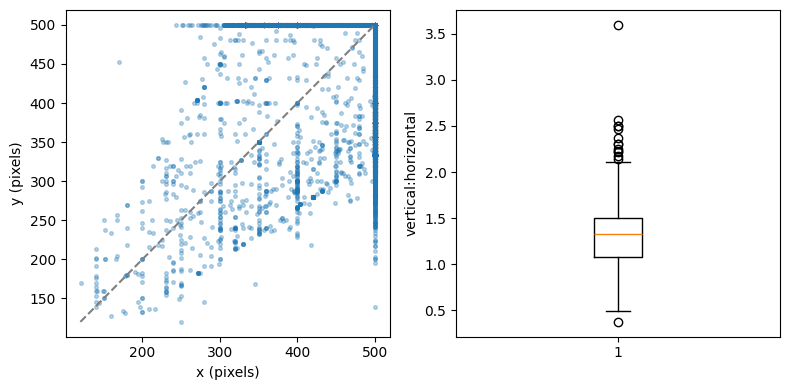

In [ ]:
# plot image pixel size data
fig, ax = plt.subplots(1,2, figsize=(8,4))

# plot scatter chart of number of x pixels by number of y pixels
ax[0].scatter(xs, ys, alpha=0.3, s=7)
ax[0].plot((min(ys),500), (min(ys),500), c='grey', linestyle='--')

# plot boxplot x/y pixels
ax[1].boxplot(ratios)

# annotation
ax[0].set_xlabel('x (pixels)')
ax[0].set_ylabel('y (pixels)')
ax[1].set_ylabel('vertical:horizontal')

fig.tight_layout()

#### 3b | Test Image Processing

ROW INDEX: 3528


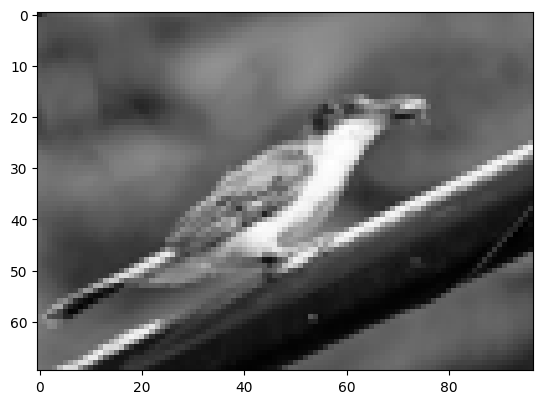

In [194]:
# pick a random image
selection = randint(1,len(processed_images))
print('ROW INDEX:',selection)

# copy and resize the image
pi = deepcopy(processed_images[selection])
pi.resize((70,97))

# show image
plt.imshow(pi, 'Greys_r')

#### 3c | Save Processed Data

In [ ]:
# save processed_images as a compressed text file
np.savetxt(
    fname='data\\birbAI_processed_image_array.gz',
    X=processed_images[1:],
    delimiter=','
)